# Notebook 01: Treinamento do Classificador de Categoria de Despesas

Este notebook tem como objetivo treinar um modelo de Machine Learning capaz de classificar descrições textuais de transações (ex: "Ifood", "Posto Shell") em categorias financeiras pré-definidas (`alimentacao`, `transporte`, `lazer`, etc.).

In [1]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
# ==========================================================
# PATHS LOCAIS
# ==========================================================

BASE = "../../data"
BASE_MODELS = "../../models"

In [3]:
# ==========================================================
# LEITURA DO DATASET
# ==========================================================

dataset_categoria = pd.read_csv(
    f"{BASE}/processed/dataset_modelo_categoria.csv"
)

dataset_categoria.head()

,descricao_transacao,valor_transacao,categoria
0,Compra online - Burger King (compra à vista),829.09,Alimentação
1,Transação - Renner (parcelado em 4x),232.37,Compras
2,Consumo em CDB Banco Inter (compra à vista),910.31,Investimentos
3,Débito - Decolar.com,421.92,Lazer
4,Pagamento de conta - Açougue Central,450.77,Alimentação


In [4]:
# ==========================================================
# VARIAVEIS
# ==========================================================

X_texto = dataset_categoria["descricao_transacao"]
X_valor = dataset_categoria["valor_transacao"]
y = dataset_categoria["categoria"]

In [5]:
# ==========================================================
# TF-IDF
# ==========================================================

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=None
)

X_texto = tfidf.fit_transform(X_texto)

In [6]:
# ==========================================================
# CONCATENACAO DA FEATURE NUMERICA
# ==========================================================

from scipy.sparse import hstack

X = hstack([X_texto, X_valor.values.reshape(-1, 1)])

In [7]:
# ==========================================================
# DIVISAO TREINO / TESTE
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
# ==========================================================
# TREINAMENTO
# ==========================================================

modelo_categoria = MultinomialNB()
modelo_categoria.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [9]:
# ==========================================================
# PREDICAO
# ==========================================================

predicoes = modelo_categoria.predict(X_test)

In [10]:
# ==========================================================
# METRICAS DE AVALIACAO
# ==========================================================

accuracy = accuracy_score(y_test, predicoes)
precision = precision_score(y_test, predicoes, average="macro")
recall = recall_score(y_test, predicoes, average="macro")
f1 = f1_score(y_test, predicoes, average="macro")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.9838
Precision: 0.9860
Recall   : 0.9826
F1-Score : 0.9836


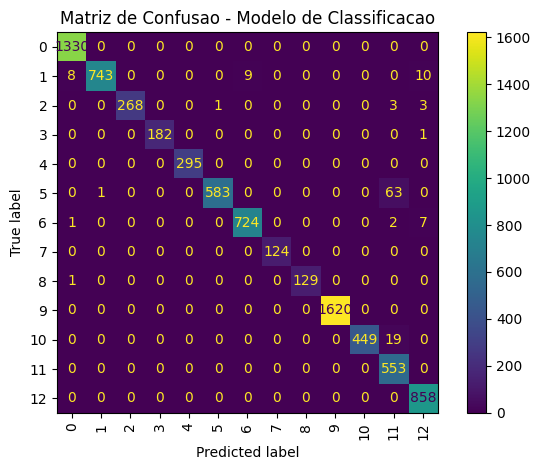

In [11]:
# ==========================================================
# MATRIZ DE CONFUSAO
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicoes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(xticks_rotation=90)
plt.title("Matriz de Confusao - Modelo de Classificacao")
plt.tight_layout()
plt.show()

In [12]:
# ==========================================================
# RELATORIO DE CLASSIFICACAO
# ==========================================================

print(classification_report(y_test, predicoes, digits=4))

               precision    recall  f1-score   support

  Alimentação     0.9925    1.0000    0.9963      1330
      Compras     0.9987    0.9649    0.9815       770
     Educação     1.0000    0.9745    0.9871       275
     Impostos     1.0000    0.9945    0.9973       183
Investimentos     1.0000    1.0000    1.0000       295
        Lazer     0.9983    0.9011    0.9472       647
      Moradia     0.9877    0.9864    0.9870       734
       Outros     1.0000    1.0000    1.0000       124
         Pets     1.0000    0.9923    0.9961       130
     Receitas     1.0000    1.0000    1.0000      1620
        Saúde     1.0000    0.9594    0.9793       468
     Serviços     0.8641    1.0000    0.9271       553
   Transporte     0.9761    1.0000    0.9879       858

     accuracy                         0.9838      7987
    macro avg     0.9860    0.9826    0.9836      7987
 weighted avg     0.9854    0.9838    0.9840      7987



In [13]:
# ==========================================================
# SALVANDO MODELO 1
# ==========================================================

import os

os.makedirs(BASE_MODELS, exist_ok=True)

joblib.dump(modelo_categoria, f"{BASE_MODELS}/modelo_categoria.joblib")
joblib.dump(tfidf, f"{BASE_MODELS}/tfidf.joblib")

print("Modelo de classificacao treinado com sucesso.")

Modelo de classificacao treinado com sucesso.


In [14]:
# ==========================================================
# VALIDACAO CRUZADA
# ==========================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    modelo_categoria,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("========== Validacao Cruzada ==========")
print(f"F1 Macro por Fold: {scores}")
print(f"F1 Macro Medio: {scores.mean():.4f}")
print(f"Desvio Padrao: {scores.std():.4f}")

========== Validacao Cruzada ==========
F1 Macro por Fold: [0.98301676 0.98090856 0.98180682 0.97946777 0.98012965]
F1 Macro Medio: 0.9811
Desvio Padrao: 0.0012


## Conclusao

O modelo Multinomial Naive Bayes, treinado sobre a vetorizacao TF-IDF das descricoes de transacao combinada ao valor da transacao, apresentou desempenho consistente entre o conjunto de teste e a validacao cruzada, indicando boa capacidade de generalizacao para classificar novas descricoes em categorias financeiras.